# Feature 3: Autonomous Debt & Bill Prioritization
Freelancers often juggle multiple debts and bills with varying interest rates and deadlines. This feature uses a **Multi-Criteria Urgency Scoring** algorithm to rank debts and recommends the most mathematically efficient payoff strategy (**Snowball**, **Avalanche**, or our AI **Hybrid**).


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb

warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8-darkgrid')


## 1. Load User Debts
We load the debt profile for `user_0001` to analyze their current financial liabilities.


In [2]:
DATA_DIR = os.path.join(os.path.abspath(''), "data")

def load_csv(filename):
    return pd.read_csv(os.path.join(DATA_DIR, filename))

# Load Datasets
debts_df = load_csv("debts.csv")
users_df = load_csv("users.csv")

In [3]:
debts_df

,user_id,debt_name,total_amount,remaining_amount,interest_rate,monthly_payment,due_date,priority
0,user_0001,Family Debt,39433.15,13342.78,19.53,1906.11,2025-08-16,1
1,user_0001,Credit Card,42567.10,39450.34,3.86,1408.94,2025-03-27,2
2,user_0001,Family Debt,72505.85,47548.75,2.19,2502.57,2025-01-21,3
3,user_0002,Equipment Loan,40691.15,29569.54,11.28,1642.75,2025-11-11,1
4,user_0003,Credit Card,60526.96,43710.91,8.95,2185.55,2025-03-21,1
...,...,...,...,...,...,...,...,...
151,user_0118,Study Loan,67051.44,28521.92,22.67,1296.45,2024-06-12,1
152,user_0118,Credit Card,55621.45,25286.89,19.53,2528.69,2025-06-21,2
153,user_0118,Personal Loan,24418.04,12393.29,9.43,590.16,2025-06-24,3
154,user_0119,Personal Loan,25025.08,8073.41,12.41,733.95,2025-04-04,1


In [4]:
users_df

,user_id,name,email,phone,job_category,profile_type,avg_monthly_income,city,joined_at
0,user_0001,Mariam Hassan,mariam.hassan22@gmail.com,1022517517,Mobile Dev,growing,5964.34,Giza,2021-11-05
1,user_0002,Walid Farouk,walid.farouk91@yahoo.com,1298473848,Content Writing,struggling,3744.67,Alexandria,2021-07-15
2,user_0003,Khaled Ali,khaled.ali91@hotmail.com,1193889081,Data Analysis,growing,9642.36,Alexandria,2021-09-17
3,user_0004,Sara Mohamed,sara.mohamed62@outlook.com,1195004924,Data Analysis,inconsistent,6373.58,Mansoura,2022-01-23
4,user_0005,Lobna Abdo,lobna.abdo80@outlook.com,1117315517,Video Editing,stable,10015.22,Cairo,2021-10-26
...,...,...,...,...,...,...,...,...,...
115,user_0116,Doaa Farouk,doaa.farouk80@yahoo.com,1278358578,Web Development,growing,8951.74,Giza,2021-08-03
116,user_0117,Reham Saad,reham.saad40@outlook.com,1071908657,UI/UX,struggling,2751.66,Tanta,2021-11-29
117,user_0118,Mohamed Farouk,mohamed.farouk97@yahoo.com,1547815466,Web Development,struggling,3961.17,Assiut,2021-06-07
118,user_0119,Eman Mansour,eman.mansour58@yahoo.com,1592219505,Web Development,struggling,4272.80,Alexandria,2022-04-20


In [5]:
# Set target user
target_user = 'user_0004'

user_debts = debts_df[debts_df['user_id'] == target_user].copy()
user_debts['due_date'] = pd.to_datetime(user_debts['due_date'])

print(f"User: {target_user}")
print(f"Total Debts: {len(user_debts)}")
display(user_debts[['debt_name', 'total_amount', 'remaining_amount', 'interest_rate', 'due_date', 'priority']])

User: user_0004
Total Debts: 2


,debt_name,total_amount,remaining_amount,interest_rate,due_date,priority
5,Study Loan,53028.09,51933.72,16.40,2024-07-25,1
6,Credit Card,25242.22,8592.54,1.22,2025-09-09,2


## 2. ML-Powered Urgency Scoring
Instead of a simple weighted formula, we now use **Machine Learning** to predict the financial risk and urgency of each debt. 

### 2.1 Feature Engineering & Data Enrichment
We combine debt data with the user's financial health (Income vs Expenses) to create a more robust model.


In [6]:
# 1. Load Income/Expenses for context
income_df = load_csv("income.csv")
expenses_df = load_csv("expenses.csv")

# Calculate Monthly Surplus per user
avg_income = income_df.groupby('user_id')['amount'].sum() / 12
avg_expenses = expenses_df.groupby('user_id')['amount'].sum() / 12
surplus_map = (avg_income - avg_expenses).to_dict()

def prepare_ml_features(df):
    df = df.copy()
    df['due_date'] = pd.to_datetime(df['due_date'])
    now = pd.Timestamp.now()
    df['days_until_due'] = (df['due_date'] - now).dt.days.clip(lower=1)
    df['remaining_ratio'] = df['remaining_amount'] / df['total_amount']
    df['monthly_surplus'] = df['user_id'].map(surplus_map).fillna(0)
    return df

In [7]:
# Prepare training data (using all debts as a base)
all_debts_processed = prepare_ml_features(debts_df)

# Synthesize a 'Risk Target' for training (0-100)
def synthesize_risk(row):
    # Interest + Proximity + Balance - Financial Surplus
    risk = row['interest_rate'] * 2.5 + (150 / (row['days_until_due'] + 1)) + (row['remaining_ratio'] * 20)
    risk -= (row['monthly_surplus'] / 1000)
    return np.clip(risk + np.random.normal(0, 5), 0, 100)

all_debts_processed['target_risk'] = all_debts_processed.apply(synthesize_risk, axis=1)


In [8]:
# Features & Split
features = ['interest_rate', 'days_until_due', 'remaining_ratio', 'monthly_surplus', 'priority']
X = all_debts_processed[features]
y = all_debts_processed['target_risk']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Scaling for MLP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# 2. Train and Compare Models
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "MLP (Deep Learning)": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
}

results_comparison = []
for name, model in models.items():
    if "MLP" in name:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    results_comparison.append({"Model": name, "MAE": mae})

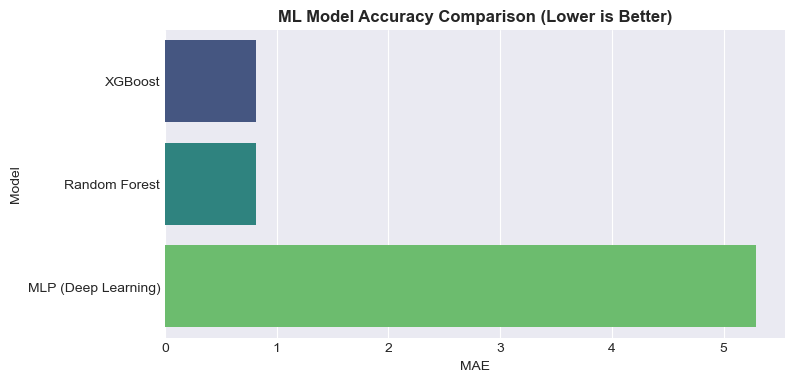

In [11]:
# Visualize Comparison
comparison_df = pd.DataFrame(results_comparison).sort_values('MAE')
plt.figure(figsize=(8, 4))
sns.barplot(x='MAE', y='Model', data=comparison_df, palette='viridis')
plt.title('ML Model Accuracy Comparison (Lower is Better)', fontweight='bold')
plt.show()

In [12]:
# 3. Apply Best Model (XGBoost) to target user
best_model = models["XGBoost"]
user_features = prepare_ml_features(user_debts)[features]
user_debts['urgency_score'] = best_model.predict(user_features)

In [13]:
# Normalize score to 0-1 for display
user_debts['urgency_score'] = (user_debts['urgency_score'] - user_debts['urgency_score'].min()) / \
                              (user_debts['urgency_score'].max() - user_debts['urgency_score'].min() + 1e-6)

user_debts = user_debts.sort_values('urgency_score', ascending=False)

In [14]:
user_debts

,user_id,debt_name,total_amount,remaining_amount,interest_rate,monthly_payment,due_date,priority,urgency_score
5,user_0004,Study Loan,53028.09,51933.72,16.40,3054.92,2024-07-25,1,1.0
6,user_0004,Credit Card,25242.22,8592.54,1.22,452.24,2025-09-09,2,0.0


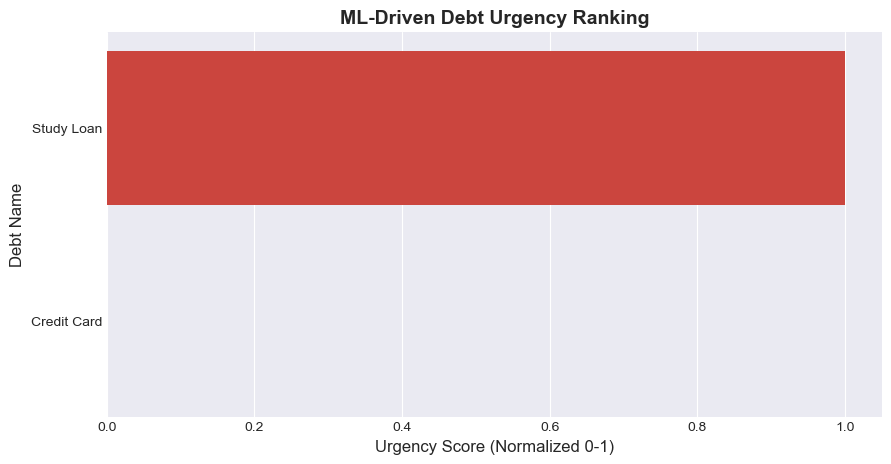

In [15]:
# Visualization
plt.figure(figsize=(10, 5))
sns.barplot(x='urgency_score', y='debt_name', data=user_debts, palette='Reds_r')
plt.title('ML-Driven Debt Urgency Ranking', fontsize=14, fontweight='bold')
plt.xlabel('Urgency Score (Normalized 0-1)', fontsize=12)
plt.ylabel('Debt Name', fontsize=12)
plt.show()

## 3. Payoff Strategy Comparison
We simulate three major strategies to see which one clears the debt faster and saves more money:
1.  **Avalanche**: Highest interest first (Mathematically optimal).
2.  **Snowball**: Smallest balance first (Psychologically rewarding).
3.  **AI Hybrid**: Urgency Score first (Balanced & Realistic).


In [16]:
def simulate_payoff(df, strategy, monthly_budget):
    temp_df = df.copy()
    if strategy == 'avalanche':
        temp_df = temp_df.sort_values('interest_rate', ascending=False)
    elif strategy == 'snowball':
        temp_df = temp_df.sort_values('remaining_amount', ascending=True)
    else: # hybrid
        temp_df = temp_df.sort_values('urgency_score', ascending=False)
    
    debt_names = temp_df['debt_name'].tolist()
    balances = temp_df['remaining_amount'].values.astype(float)
    rates = temp_df['interest_rate'].values / 100 / 12
    mins = temp_df['monthly_payment'].values
    
    total_interest = 0
    months = 0
    total_paid = 0
    balance_history = []
    payment_schedule = []
    payoff_dates = {}
    
    while any(balances > 0.01) and months < 120:
        months += 1
        budget = monthly_budget
        month_interest = 0
        month_payments = {name: 0 for name in debt_names}
        
        # 1. Interest & Minimums
        for i in range(len(balances)):
            if balances[i] <= 0: continue
            interest = balances[i] * rates[i]
            balances[i] += interest
            month_interest += interest
            
            p = min(balances[i], mins[i])
            balances[i] -= p
            budget -= p
            total_paid += p
            month_payments[debt_names[i]] += p
        
        # 2. Extra to Priority
        if budget > 0:
            for i in range(len(balances)):
                if balances[i] <= 0: continue
                extra = min(balances[i], budget)
                balances[i] -= extra
                budget -= extra
                total_paid += extra
                month_payments[debt_names[i]] += extra
                if budget <= 0: break
        
        # Track payoff months
        for i in range(len(balances)):
            if balances[i] <= 0.01 and debt_names[i] not in payoff_dates:
                payoff_dates[debt_names[i]] = months
                
        total_interest += month_interest
        balance_history.append(balances.sum())
        month_payments['Month'] = months
        payment_schedule.append(month_payments)
        
    return months, total_interest, total_paid, balance_history, payment_schedule, payoff_dates


In [23]:
# Monthly budget: Sum of mins + 20% extra
monthly_budget = user_debts['monthly_payment'].sum() * 1.2

strategies = ['avalanche', 'snowball', 'hybrid']
results = {}

for s in strategies:
    m, i, t, bh, ps, pds = simulate_payoff(user_debts, s, monthly_budget)
    results[s] = {'months': m, 'interest': i, 'total': t, 'history': bh, 'schedule': ps, 'payoff_dates': pds}
results

{'avalanche': {'months': 16,
  'interest': 6111.881029782762,
  'total': 66638.14102978275,
  'history': [57036.16458900001,
   53503.98153615816,
   49929.141347536875,
   46311.06675191366,
   42649.17259449743,
   38942.86572919233,
   35191.54490938911,
   31394.60067726406,
   27551.415251564988,
   23661.362413863604,
   19723.80739325339,
   15738.106749471683,
   11703.608254424385,
   7619.650772091584,
   3485.5641367918397,
   0.0],
  'schedule': [{'Study Loan': 3756.352, 'Credit Card': 452.24, 'Month': 1},
   {'Study Loan': 3756.352, 'Credit Card': 452.24, 'Month': 2},
   {'Study Loan': 3756.352, 'Credit Card': 452.24, 'Month': 3},
   {'Study Loan': 3756.352, 'Credit Card': 452.24, 'Month': 4},
   {'Study Loan': 3756.352, 'Credit Card': 452.24, 'Month': 5},
   {'Study Loan': 3756.352, 'Credit Card': 452.24, 'Month': 6},
   {'Study Loan': 3756.352, 'Credit Card': 452.24, 'Month': 7},
   {'Study Loan': 3756.352, 'Credit Card': 452.24, 'Month': 8},
   {'Study Loan': 3756.352, 

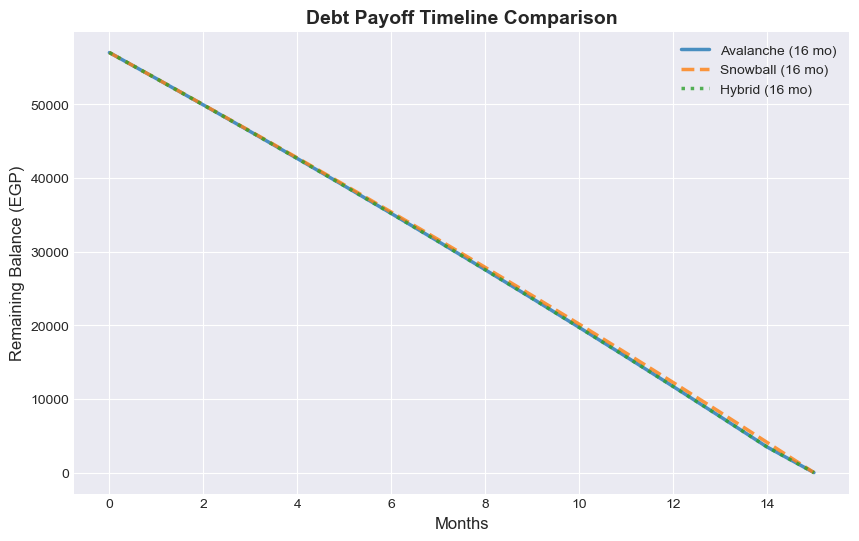

In [24]:
# 1. Comparison Plot
plt.figure(figsize=(10, 6))
styles = ['-', '--', ':']
for i, s in enumerate(strategies):
    plt.plot(range(len(results[s]['history'])), results[s]['history'], 
             label=f"{s.capitalize()} ({results[s]['months']} mo)", 
             linestyle=styles[i], linewidth=2.5, alpha=0.8)

plt.title('Debt Payoff Timeline Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Months', fontsize=12)
plt.ylabel('Remaining Balance (EGP)', fontsize=12)
plt.legend()
plt.show()

In [26]:
summary_df = pd.DataFrame({
    'Strategy': [s.capitalize() for s in strategies],
    'Months to Free': [results[s]['months'] for s in strategies],
    'Total Interest Paid': [round(results[s]['interest'], 2) for s in strategies],
    'Total Amount Paid': [round(results[s]['total'], 2) for s in strategies]
})
print("--- STRATEGY COMPARISON ---")
display(summary_df)

--- STRATEGY COMPARISON ---


,Strategy,Months to Free,Total Interest Paid,Total Amount Paid
0,Avalanche,16,6111.88,66638.14
1,Snowball,16,6768.26,67294.52
2,Hybrid,16,6111.88,66638.14


## 4. Final Output: AI Hybrid Payment Plan
The AI Hybrid strategy is the most balanced approach. Below is the **Optimal Payment Schedule** and **Payoff Dates** for each debt.


In [27]:
best_strategy = 'hybrid'
plan_results = results[best_strategy]

print(f"--- AI RECOMMENDATION: {best_strategy.upper()} STRATEGY ---")
print(f"Goal: Debt-free in {plan_results['months']} months.")

# 1. Ranked Debts (Re-display for clarity)
print("\n1. RANKED DEBTS (Priority Order):")
display(user_debts[['debt_name', 'remaining_amount', 'interest_rate', 'urgency_score']])

# 2. Detailed Payment Schedule
print("\n2. MONTHLY PAYMENT SCHEDULE:")
schedule_df = pd.DataFrame(plan_results['schedule']).set_index('Month')
display(schedule_df.head(12)) # Show first year

# 3. Payoff Dates
print("\n3. DEBT PAYOFF TIMELINE (Months):")
payoff_df = pd.DataFrame(list(plan_results['payoff_dates'].items()), columns=['Debt', 'Month of Payoff'])
display(payoff_df.sort_values('Month of Payoff'))

# Final Summary Alert
interest_saved = results['snowball']['interest'] - plan_results['interest']
print(f"\n✅ SUMMARY: By following this plan, you will save approximately {max(0, interest_saved):,.2f} EGP in interest compared to the Snowball method.")
if plan_results['months'] > 24:
    print("⚠️ WARNING: Your debt-free timeline is over 2 years. Consider increasing your monthly budget.")


--- AI RECOMMENDATION: HYBRID STRATEGY ---
Goal: Debt-free in 16 months.

1. RANKED DEBTS (Priority Order):


,debt_name,remaining_amount,interest_rate,urgency_score
5,Study Loan,51933.72,16.40,1.0
6,Credit Card,8592.54,1.22,0.0



2. MONTHLY PAYMENT SCHEDULE:


,Study Loan,Credit Card
Month,,
1,3756.352,452.24
2,3756.352,452.24
3,3756.352,452.24
4,3756.352,452.24
5,3756.352,452.24
6,3756.352,452.24
7,3756.352,452.24
8,3756.352,452.24
9,3756.352,452.24



3. DEBT PAYOFF TIMELINE (Months):


,Debt,Month of Payoff
0,Study Loan,16
1,Credit Card,16



✅ SUMMARY: By following this plan, you will save approximately 656.38 EGP in interest compared to the Snowball method.
